<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/11_amaliy_faollashtirish_funksiyalari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf # Neyron tarmoq kutubxonasi
import numpy as np  # Matematik hisob
import matplotlib.pyplot as plt # MNIST rasm dataseti

MNIST nima?
┌───────────────────────────────────┐
│  0  1  2  3  4  5  6  7  8  9   │
│  ✍️  ✍️  ✍️  ✍️  ✍️  ✍️  ✍️  ✍️  ✍️  ✍️  │
└───────────────────────────────────┘
  Har bir rasm: 28×28 piksel, kulrang
  Train: 60,000 ta | Test: 10,000 ta

In [ ]:
#Dataset (MNIST)
from tensorflow.keras.datasets import mnist
# Dataset yuklash
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normallashtirish
X_train = X_train / 255.0
X_test = X_test / 255.0
#  X_train → (60000, 28, 28)  # 60000 ta rasm, har biri 28×28
#  y_train → (60000,)          # 60000 ta javob: 0–9 raqamlar
#  X_test  → (10000, 28, 28)
#  y_test  → (10000,)
## Flatten (28x28 → 784)

Piksel qiymatlari:
**Текст, выделенный полужирным шрифтом**  
Oldin:  [0 ... 255]   ← butun son
Keyin:  [0.0 ... 1.0] ← kasr son

Nimaga?
  255 → 1.0  (oq rang)
  0   → 0.0  (qora rang)
  128 → 0.502 (kulrang)

  Model kichik sonlar bilan tezroq va yaxshiroq o'rganadi

In [ ]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)
# -1 → numpy 60000 ni o'zi hisoblaydi
# 784 → har qator 784 ta element

Oldin:  (60000, 28, 28)  ← 2D rasm
          
           60000 ta      28×28 matritsa

Keyin:  (60000, 784)     ← 1D vektor

           60000 ta   784 ta son (28×28=784)

MNIST yuklash

       ↓

  (60000, 28, 28) + (60000,)

       ↓

  / 255.0  →  [0, 1] oralig'iga

       ↓

  reshape(-1, 784)  →  (60000, 784)

       ↓

  Neyron tarmoqqa tayyor!

In [ ]:
#Model funksiyasi (aktivatsiyani parametr sifatida)
from tensorflow.keras import layers, models

def create_model(activation_func):
    model = models.Sequential([
        layers.Dense(128, activation=activation_func, input_shape=(784,)),
        layers.Dense(64, activation=activation_func),
        layers.Dense(10, activation='softmax')
    ])
    # # Keras Dense — neyron tarmoq
# Dense (to'liq ulangan / fully connected) — har bir neyron oldingi qatlamning barcha neyronlari bilan bog'langan qatlam.
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Modelni o‘qitish (3 xil aktivatsiya)
activations = ['relu', 'sigmoid', 'tanh']
histories = {}

for act in activations:
    print(f"\nTraining with {act}")
    model = create_model(act)

    history = model.fit(
        X_train, y_train,
        epochs=5,
        validation_data=(X_test, y_test),
        verbose=1
    )

    histories[act] = history


Training with relu
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9325 - loss: 0.2270 - val_accuracy: 0.9654 - val_loss: 0.1173
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9703 - loss: 0.0952 - val_accuracy: 0.9684 - val_loss: 0.0984
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9787 - loss: 0.0689 - val_accuracy: 0.9731 - val_loss: 0.0839
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9835 - loss: 0.0522 - val_accuracy: 0.9768 - val_loss: 0.0792
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0422 - val_accuracy: 0.9778 - val_loss: 0.0750

Training with sigmoid
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8847 - loss: 0.4632 - val_accuracy: 0.9373 - val_loss: 0.2095
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9486 - loss: 0.1748 - val_accuracy: 0.9548 - val_loss: 0.1446
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step -

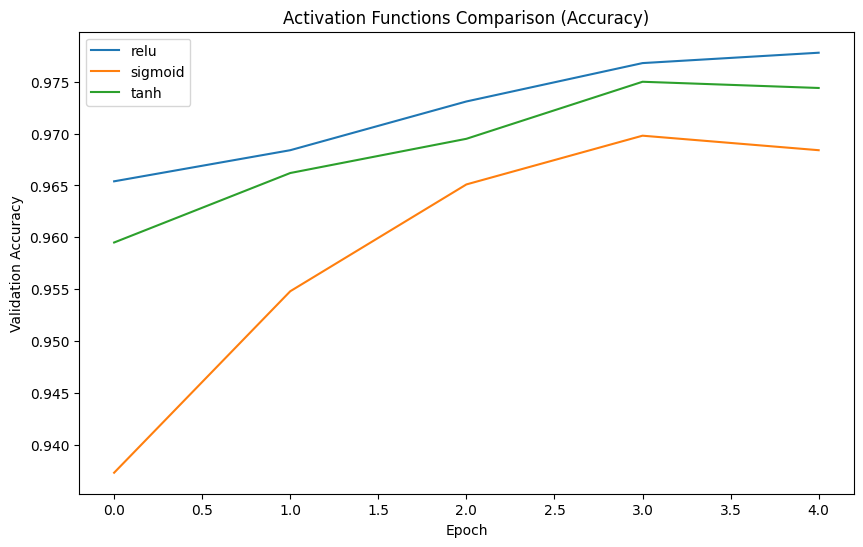

In [ ]:
# Grafik chizish (Accuracy)
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act)

plt.title("Activation Functions Comparison (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

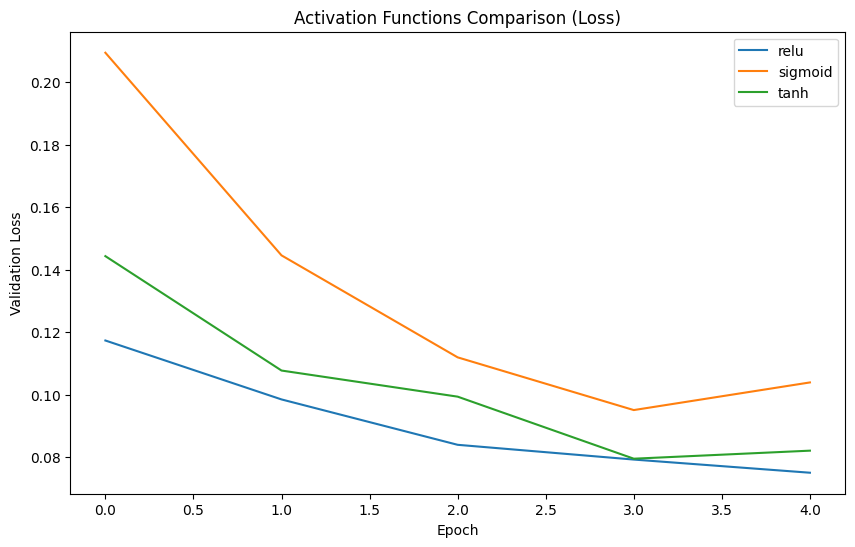

In [ ]:
# Grafik chizish (Loss)
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)

plt.title("Activation Functions Comparison (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [ ]:
for act in activations:
    acc = histories[act].history['val_accuracy'][-1]
    print(f"{act} final accuracy: {acc:.4f}")

relu final accuracy: 0.9778
sigmoid final accuracy: 0.9684
tanh final accuracy: 0.9744


Activation Functions (Fashion MNIST)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataset yuklash
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normallashtirish
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Class nomlari (tushunarli qilish uchun)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [ ]:
# Model funksiyasi
from tensorflow.keras import layers, models

def create_model(activation_func):
    model = models.Sequential([
        layers.Dense(128, activation=activation_func, input_shape=(784,)),
        layers.Dense(64, activation=activation_func),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Modelni o‘qitish (3 aktivatsiya)
activations = ['relu', 'sigmoid', 'tanh']
histories = {}

for act in activations:
    print(f"\nTraining with {act}")
    model = create_model(act)

    history = model.fit(
        X_train, y_train,
        epochs=5,
        validation_data=(X_test, y_test),
        verbose=1
    )

    histories[act] = history


Training with relu
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8238 - loss: 0.4955 - val_accuracy: 0.8488 - val_loss: 0.4202
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8660 - loss: 0.3697 - val_accuracy: 0.8516 - val_loss: 0.4133
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8778 - loss: 0.3349 - val_accuracy: 0.8641 - val_loss: 0.3754
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8845 - loss: 0.3141 - val_accuracy: 0.8680 - val_loss: 0.3599
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8912 - loss: 0.2947 - val_accuracy: 0.8646 - val_loss: 0.3764

Training with sigmoid
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7966 - loss: 0.6116 - val_accuracy: 0.8316 - val_loss: 0.4598
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8593 - loss: 0.3860 - val_accuracy: 0.8555 - val_loss: 0.3985
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step -

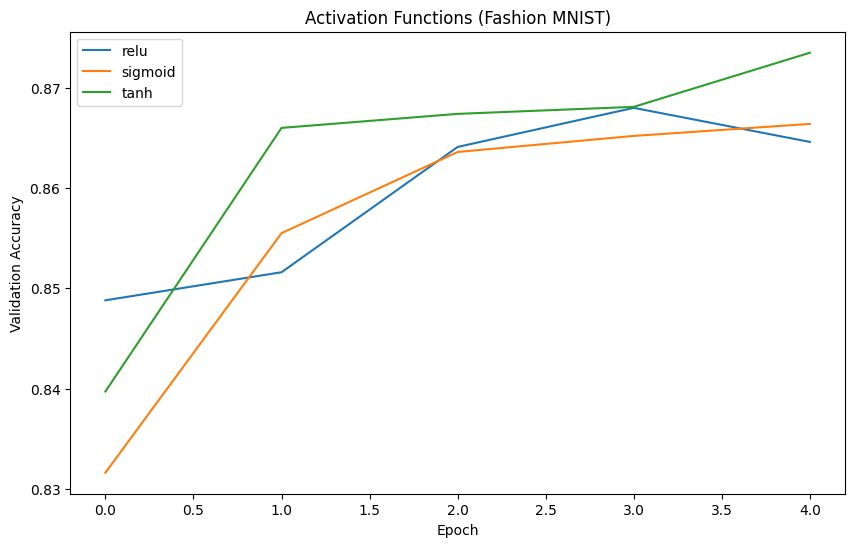

In [ ]:
# Accuracy grafik
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act)

plt.title("Activation Functions (Fashion MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

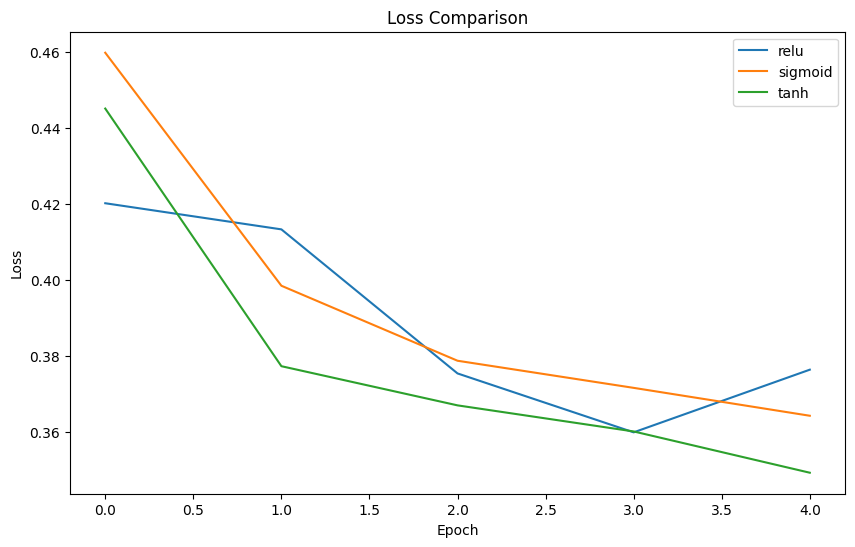

In [ ]:
# Loss grafik
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()